In [51]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\all_fuels_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 

  ticker  commodity        date       open       high        low      close  \
0   CL=F  Crude Oil  2000-08-23  31.950001  32.799999  31.950001  32.049999   
1   CL=F  Crude Oil  2000-08-24  31.900000  32.240002  31.400000  31.629999   
2   CL=F  Crude Oil  2000-08-25  31.700001  32.099998  31.320000  32.049999   
3   CL=F  Crude Oil  2000-08-28  32.040001  32.919998  31.860001  32.869999   
4   CL=F  Crude Oil  2000-08-29  32.820000  33.029999  32.560001  32.720001   

   volume  
0   79385  
1   72978  
2   44601  
3   46770  
4   49131  


In [53]:
print(df['commodity'].unique())

['Crude Oil' 'Heating Oil' 'Natural Gas' 'RBOB Gasoline' 'Brent Crude Oil']


In [54]:
print(df.columns)


Index(['ticker', 'commodity', 'date', 'open', 'high', 'low', 'close',
       'volume'],
      dtype='object')


In [55]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28075 entries, 0 to 28074
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ticker     28075 non-null  object 
 1   commodity  28075 non-null  object 
 2   date       28075 non-null  object 
 3   open       28075 non-null  float64
 4   high       28075 non-null  float64
 5   low        28075 non-null  float64
 6   close      28075 non-null  float64
 7   volume     28075 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 1.7+ MB
None


In [56]:
print(df.isnull().sum())

ticker       0
commodity    0
date         0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


In [57]:
# Đảm bảo cột ngày là định dạng datetime
df['date'] = pd.to_datetime(df['date'])

# Trích xuất thêm thông tin từ ngày
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek


In [58]:
import matplotlib.pyplot as plt

# Khởi tạo dictionary để lưu giá trị thực tế và dự đoán
results = {}

commodities = df['commodity'].unique()

for com in commodities:
    df_com = df[df['commodity'] == com].copy()

    # Tiền xử lý
    df_com['date'] = pd.to_datetime(df_com['date'])
    df_com['year'] = df_com['date'].dt.year
    df_com['month'] = df_com['date'].dt.month
    df_com['day'] = df_com['date'].dt.day
    df_com['dayofweek'] = df_com['date'].dt.dayofweek

    features = ['open', 'high', 'low', 'volume', 'year', 'month', 'day', 'dayofweek']
    target = 'close'

    X = df_com[features]
    y = df_com[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = CatBoostRegressor(verbose=0)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Lưu kết quả
    results[com] = {
        'actual': y_test.reset_index(drop=True),
        'predicted': pd.Series(y_pred)
    }


In [ ]:
results = {}  # Tạo dict để lưu kết quả dự đoán

for com in commodities:
    print(f"\n--- Đang huấn luyện mô hình cho: {com} ---")
    
    df_com = df[df['commodity'] == com].copy()
    df_com['date'] = pd.to_datetime(df_com['date'])
    df_com['year'] = df_com['date'].dt.year
    df_com['month'] = df_com['date'].dt.month
    df_com['day'] = df_com['date'].dt.day
    df_com['dayofweek'] = df_com['date'].dt.dayofweek

    features = ['open', 'high', 'low', 'volume', 'year', 'month', 'day', 'dayofweek']
    target = 'close'
    
    X = df_com[features]
    y = df_com[target]
    dates = df_com['date']

    X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
        X, y, dates, test_size=0.2, shuffle=False)

    model = CatBoostRegressor(
        iterations=800,
        depth=6,
        learning_rate=0.01, #0.05
        loss_function='RMSE',
        verbose=0
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Lưu kết quả để trực quan
    results[com] = pd.DataFrame({
        'date': dates_test.reset_index(drop=True),
        'actual': y_test.reset_index(drop=True),
        'predicted': y_pred
    })



--- Đang huấn luyện mô hình cho: Crude Oil ---



--- Đang huấn luyện mô hình cho: Heating Oil ---

--- Đang huấn luyện mô hình cho: Natural Gas ---

--- Đang huấn luyện mô hình cho: RBOB Gasoline ---

--- Đang huấn luyện mô hình cho: Brent Crude Oil ---


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dự đoán và tính toán lỗi cho từng commodity
for com in commodities:
    # Tính các độ lỗi
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # In kết quả cho từng commodity
    print(f"📌 {com} - Mean Absolute Error (MAE): {mae:.4f}")
    print(f"📌 {com} - Mean Squared Error (MSE): {mse:.4f}")
    print(f"📌 {com} - Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"📌 {com} - R-squared (R²): {r2:.4f}")


📌 Crude Oil - Mean Absolute Error (MAE): 1.7533
📌 Crude Oil - Mean Squared Error (MSE): 7.0005
📌 Crude Oil - Root Mean Squared Error (RMSE): 2.6459
📌 Crude Oil - R-squared (R²): 0.9565
📌 Heating Oil - Mean Absolute Error (MAE): 1.7533
📌 Heating Oil - Mean Squared Error (MSE): 7.0005
📌 Heating Oil - Root Mean Squared Error (RMSE): 2.6459
📌 Heating Oil - R-squared (R²): 0.9565
📌 Natural Gas - Mean Absolute Error (MAE): 1.7533
📌 Natural Gas - Mean Squared Error (MSE): 7.0005
📌 Natural Gas - Root Mean Squared Error (RMSE): 2.6459
📌 Natural Gas - R-squared (R²): 0.9565
📌 RBOB Gasoline - Mean Absolute Error (MAE): 1.7533
📌 RBOB Gasoline - Mean Squared Error (MSE): 7.0005
📌 RBOB Gasoline - Root Mean Squared Error (RMSE): 2.6459
📌 RBOB Gasoline - R-squared (R²): 0.9565
📌 Brent Crude Oil - Mean Absolute Error (MAE): 1.7533
📌 Brent Crude Oil - Mean Squared Error (MSE): 7.0005
📌 Brent Crude Oil - Root Mean Squared Error (RMSE): 2.6459
📌 Brent Crude Oil - R-squared (R²): 0.9565


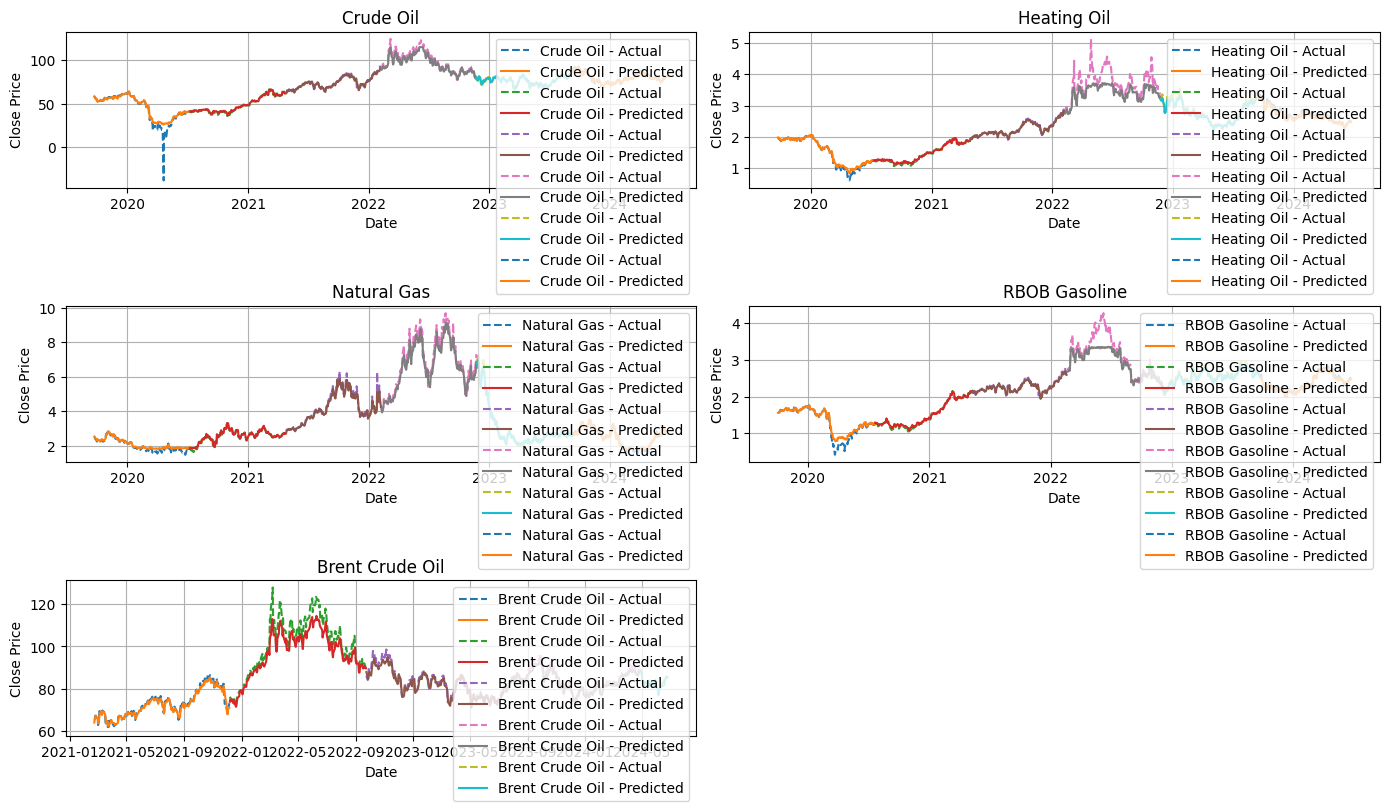

In [61]:
import matplotlib.pyplot as plt

# Thiết lập kích thước của hình vẽ
plt.figure(figsize=(14, 8))

# Số lượng biểu đồ con mà bạn muốn vẽ
num_plots = len(results)
rows = (num_plots // 2) + (num_plots % 2)  # Chia số hàng sao cho phù hợp với số biểu đồ
cols = 2  # Số cột cho mỗi hàng (bạn có thể thay đổi)

# Vẽ từng biểu đồ trong khung con
for i, (com, df_result) in enumerate(results.items()):
    plt.subplot(rows, cols, i + 1)
    for j in range(0, len(df_result), 200):  # Chia thành các nhóm 200 dòng
        chunk = df_result.iloc[j:j + 200]
        plt.plot(chunk['date'], chunk['actual'], label=f'{com} - Actual', linestyle='--')
        plt.plot(chunk['date'], chunk['predicted'], label=f'{com} - Predicted')
    
    plt.title(f'{com}')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.grid(True)
    plt.legend()

# Tối ưu hóa layout và hiển thị
plt.tight_layout()
plt.show()


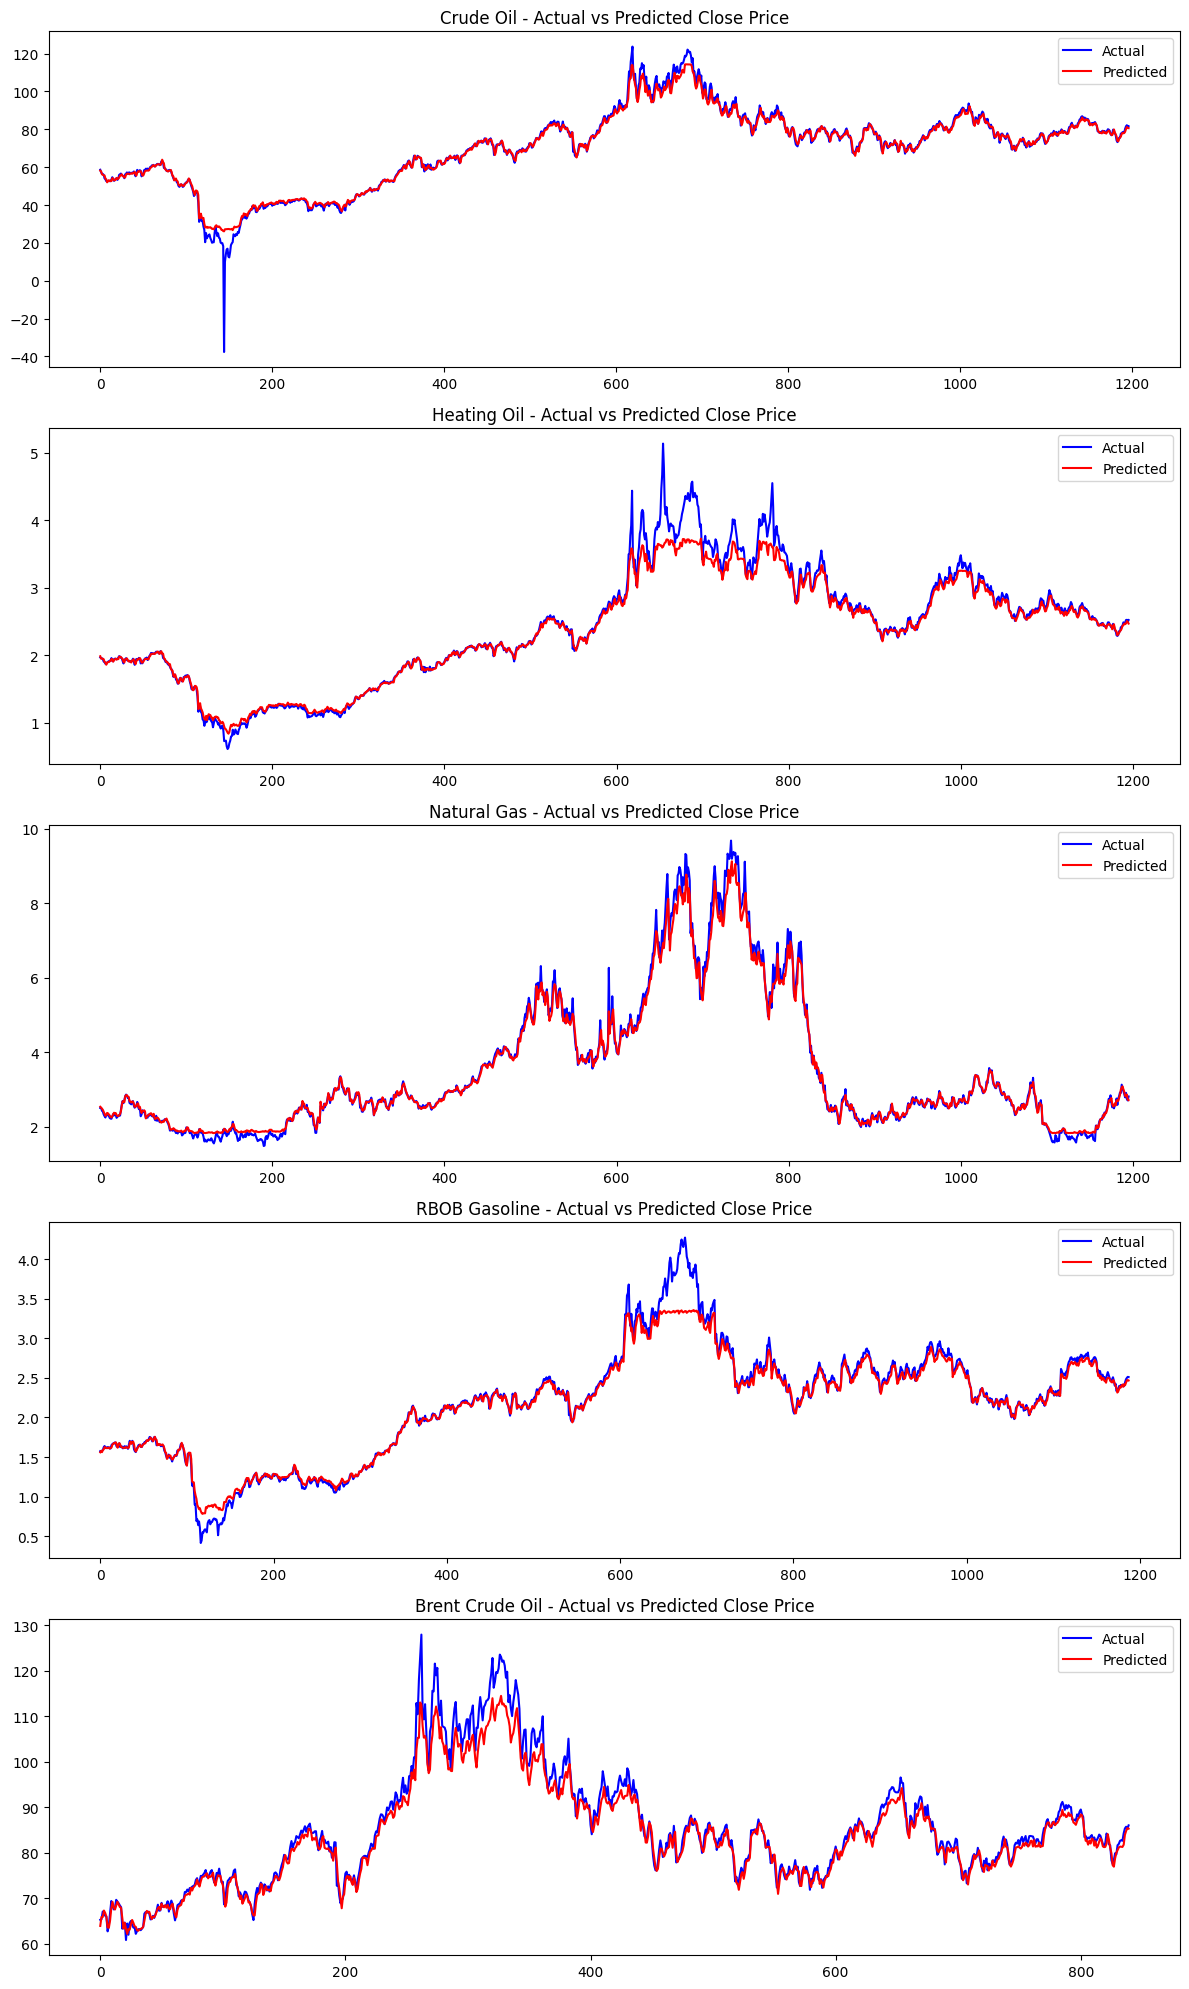

In [62]:
# Tạo subplot: mỗi commodity là 1 dòng
n = len(results)
fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=False)

if n == 1:
    axes = [axes]  # Đảm bảo axes là list nếu chỉ có 1 plot

for i, (com, res) in enumerate(results.items()):
    axes[i].plot(res['actual'], label='Actual', color='blue')
    axes[i].plot(res['predicted'], label='Predicted', color='red')
    axes[i].set_title(f"{com} - Actual vs Predicted Close Price")
    axes[i].legend()

plt.tight_layout()
plt.show()
